In [1]:

# ── Cell 1: Setup — load avg-rent and pct-change panels ──────────────────────
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

CLEAN_ROOT = Path("/home/aniket/Programming/renters/data/cmhc-rental-clean")
avg_dir = CLEAN_ROOT / "avg-rent"
pct_dir = CLEAN_ROOT / "pct-change-rent"

# Build long-format panel from avg-rent CSVs
avg_records = []
for path in sorted(avg_dir.glob("*.csv")):
    city = path.stem
    df = pd.read_csv(path)[["Year", "Total"]].rename(columns={"Total": "avg_rent"})
    df["city"] = city
    avg_records.append(df)

avg_panel = pd.concat(avg_records, ignore_index=True).dropna(subset=["avg_rent"])

# Build long-format panel from pct-change CSVs
pct_records = []
for path in sorted(pct_dir.glob("*.csv")):
    city = path.stem
    df = pd.read_csv(path)[["Year", "Total"]].rename(columns={"Total": "rent_pct"})
    df["city"] = city
    pct_records.append(df)

pct_panel = pd.concat(pct_records, ignore_index=True).dropna(subset=["rent_pct"])

# Merge into one panel
panel = avg_panel.merge(pct_panel, on=["city", "Year"], how="outer")

# Label eras:
#   early:     1990–2010 (long-run historical baseline)
#   pre_2018:  2011–2017 (rent-control era for comparison)
#   post_2018: 2019–2025 (post-deregulation)
#   2018 excluded as transition year
def label_era(yr):
    if 1990 <= yr <= 2010: return "early"
    if 2011 <= yr <= 2017: return "pre_2018"
    if 2019 <= yr <= 2025: return "post_2018"
    return "other"

panel["era"] = panel["Year"].apply(label_era)

cities = sorted(panel["city"].unique())
print(f"Cities: {len(cities)}")
print(f"Years:  {panel['Year'].min()}–{panel['Year'].max()}")
print(f"Rows:   {len(panel)}")
print()
print("Era obs (pct rows):")
print(pct_panel.assign(era=pct_panel["Year"].apply(label_era))
      .query("era != 'other'").groupby("era").size().to_string())
panel.head(6)


Cities: 33
Years:  1990–2025
Rows:   1114

Era obs (pct rows):
era
early        548
post_2018    199
pre_2018     224


,Year,avg_rent,city,rent_pct,era
0,1990,648.0,ajax,NaN,early
1,1991,709.0,ajax,4.8,early
2,1992,728.0,ajax,4.1,early
3,1993,761.0,ajax,3.3,early
4,1994,769.0,ajax,0.0,early
5,1995,755.0,ajax,0.9,early


In [2]:

# ── Cell 2: Long-run era context — mean rent growth across three eras ─────────
# Context: is post-2018 acceleration a genuine break, or just a continuation?
# Three eras: early 1990–2010, pre_2018 2011–2017, post_2018 2019–2025

era_order = ["early", "pre_2018", "post_2018"]
era_labels = {"early": "1990–2010", "pre_2018": "2011–2017", "post_2018": "2019–2025"}

pct_eras = pct_panel[pct_panel["Year"].apply(label_era) != "other"].copy()
pct_eras["era"] = pct_eras["Year"].apply(label_era)

# Overall cross-city mean and median rent growth per era
era_stats = (pct_eras.groupby("era")["rent_pct"]
             .agg(mean="mean", median="median", std="std", n="count")
             .loc[era_order].rename(index=era_labels))

print("Mean annual rent growth (%) by era — all cities pooled")
print("─" * 55)
print(era_stats.round(2).to_string())

# Per-city median for each era → shows how typical city behaved across eras
city_era_median = (pct_eras.groupby(["city", "era"])["rent_pct"]
                   .median().unstack("era")[era_order])
city_era_median.columns = [era_labels[c] for c in city_era_median.columns]

print()
print("Per-city median rent growth (%) — top/bottom 5 cities post-2018:")
post_col = era_labels["post_2018"]
print("  Top 5 (highest post-2018 growth):")
print(city_era_median.sort_values(post_col, ascending=False).head(5).round(2).to_string())
print()
print("  Bottom 5 (lowest post-2018 growth):")
print(city_era_median.sort_values(post_col).head(5).round(2).to_string())

print()
# How many cities show a monotonic increase across eras: early < pre < post?
city_era_mean = (pct_eras.groupby(["city", "era"])["rent_pct"]
                 .mean().unstack("era")[era_order])
monotonic = ((city_era_mean["early"] < city_era_mean["pre_2018"]) &
             (city_era_mean["pre_2018"] < city_era_mean["post_2018"]))
print(f"Cities with monotonically increasing era means (early < pre < post): "
      f"{monotonic.sum()}/{monotonic.count()}")
print()
print("▶  If post-2018 growth was merely a trend continuation, we'd expect early < pre < post")
print("   in most cities. But the key question is whether the post-2018 *level* is")
print("   a significant structural break beyond the pre-2018 trajectory.")


Mean annual rent growth (%) by era — all cities pooled
───────────────────────────────────────────────────────
           mean  median   std    n
era                               
1990–2010  2.33     2.1  2.09  548
2011–2017  2.64     2.6  1.32  224
2019–2025  5.00     4.9  2.57  199

Per-city median rent growth (%) — top/bottom 5 cities post-2018:
  Top 5 (highest post-2018 growth):
                 1990–2010  2011–2017  2019–2025
city                                            
greater sudbury       3.15        2.3       8.00
thunder bay           1.60        3.5       6.90
windsor               1.65        2.1       6.65
chatham-kent          1.50        2.0       6.25
brantford             2.40        3.2       6.05

  Bottom 5 (lowest post-2018 growth):
                1990–2010  2011–2017  2019–2025
city                                           
clarington           2.10       1.90        0.0
richmond hill        3.30       2.90        2.3
kawartha lakes       2.75       0.85  

In [20]:

# ── Cell 3: Statistical tests — did rent growth rate change after deregulation? ──
# Strategy:
#   a) Per-city mean pct growth per era → paired tests pre vs post (same cities both periods)
#   b) Kruskal-Wallis across all three eras (are any era means different?)
#   c) Chow test on time-trend OLS: does post-2018 represent a structural break?

# a) Per-city mean growth per era (paired: same set of cities in both periods)
city_era_mean = (pct_eras.groupby(["city", "era"])["rent_pct"]
                 .mean().unstack("era"))
paired = city_era_mean[["pre_2018", "post_2018"]].dropna()

pre_vals  = paired["pre_2018"].values
post_vals = paired["post_2018"].values
diffs     = post_vals - pre_vals

t_stat, t_p   = stats.ttest_rel(post_vals, pre_vals)
w_stat, w_p   = stats.wilcoxon(post_vals, pre_vals)
cohens_d      = diffs.mean() / diffs.std(ddof=1)
mw_stat, mw_p = stats.mannwhitneyu(post_vals, pre_vals, alternative="two-sided")

print(f"Paired city-level tests: pre_2018 vs post_2018  (n={len(paired)} cities)")
print(f"  Mean pre-2018:  {pre_vals.mean():.2f}%/yr")
print(f"  Mean post-2018: {post_vals.mean():.2f}%/yr  (Δ = +{diffs.mean():.2f} pp)")
print(f"  Paired t-test:          t={t_stat:.3f},  p={t_p:.5f}")
print(f"  Wilcoxon signed-rank:   W={w_stat:.0f},    p={w_p:.5f}")
print(f"  Mann-Whitney U:         U={mw_stat:.0f},  p={mw_p:.5f}")
print(f"  Cohen's d = {cohens_d:.3f}  ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")

# b) Kruskal-Wallis across all three eras (unpaired, pooled city-year obs)
g_early = pct_eras[pct_eras["era"] == "early"]["rent_pct"].dropna()
g_pre   = pct_eras[pct_eras["era"] == "pre_2018"]["rent_pct"].dropna()
g_post  = pct_eras[pct_eras["era"] == "post_2018"]["rent_pct"].dropna()

kw_stat, kw_p = stats.kruskal(g_early, g_pre, g_post)
print()
print(f"Kruskal-Wallis (all 3 eras, pooled obs): H={kw_stat:.3f},  p={kw_p:.6f}")

# Post-hoc pairwise Mann-Whitney with Bonferroni correction
pairs = [("early","pre_2018",g_early,g_pre),
         ("early","post_2018",g_early,g_post),
         ("pre_2018","post_2018",g_pre,g_post)]
print("  Post-hoc pairwise Mann-Whitney (Bonferroni α=0.017):")
for la, lb, a, b in pairs:
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    sig  = "✓" if p < 0.05/3 else "✗"
    print(f"    {la:12s} vs {lb:12s}  U={u:.0f}  p={p:.5f}  {sig}")

# c) Structural break: OLS annual trend on cross-city mean pct, with post-2018 dummy
yr_avg = (pct_eras.groupby(["Year","era"])["rent_pct"].mean()
          .reset_index().rename(columns={"rent_pct":"mean_pct"}))
yr_avg = yr_avg[yr_avg["era"] != "other"].copy()
yr_avg["post"] = (yr_avg["era"] == "post_2018").astype(int)
yr_avg["t"]    = yr_avg["Year"] - 2000   # centre year

from scipy.linalg import lstsq
X = np.column_stack([np.ones(len(yr_avg)), yr_avg["t"], yr_avg["post"]])
coefs, _, _, _ = lstsq(X, yr_avg["mean_pct"].values)
intercept, slope_t, coef_post = coefs
print()
print(f"OLS: mean_rent_pct ~ intercept + trend(year) + I(post_2018)")
print(f"  intercept = {intercept:.3f},  trend = {slope_t:.3f}%/yr,  "
      f"post-2018 dummy = +{coef_post:.3f}pp")
print()
print("▶  Summary:")
print(f"   • All three tests (paired-t, Wilcoxon, Mann-Whitney) reject H₀ at p<0.001.")
print(f"   • Post-2018 city-mean rent growth (+{post_vals.mean():.1f}%/yr) is roughly "
      f"{post_vals.mean()/pre_vals.mean():.1f}× the pre-2018 rate ({pre_vals.mean():.1f}%/yr).")
print(f"   • After controlling for the long-run time trend, the post-2018 structural")
print(f"     shift is +{coef_post:.2f} pp/yr — the deregulation era carries a large independent effect.")


Paired city-level tests: pre_2018 vs post_2018  (n=33 cities)
  Mean pre-2018:  2.64%/yr
  Mean post-2018: 4.95%/yr  (Δ = +2.31 pp)
  Paired t-test:          t=10.899,  p=0.00000
  Wilcoxon signed-rank:   W=3,    p=0.00000
  Mann-Whitney U:         U=1035,  p=0.00000
  Cohen's d = 1.897  (large effect)

Kruskal-Wallis (all 3 eras, pooled obs): H=184.136,  p=0.000000
  Post-hoc pairwise Mann-Whitney (Bonferroni α=0.017):
    early        vs pre_2018      U=51928  p=0.00077  ✓
    early        vs post_2018     U=21388  p=0.00000  ✓
    pre_2018     vs post_2018     U=8488  p=0.00000  ✓

OLS: mean_rent_pct ~ intercept + trend(year) + I(post_2018)
  intercept = 2.577,  trend = -0.027%/yr,  post-2018 dummy = +3.034pp

▶  Summary:
   • All three tests (paired-t, Wilcoxon, Mann-Whitney) reject H₀ at p<0.001.
   • Post-2018 city-mean rent growth (+4.9%/yr) is roughly 1.9× the pre-2018 rate (2.6%/yr).
   • After controlling for the long-run time trend, the post-2018 structural
     shift is +3.

In [3]:

# ── Cell 4: Counterfactual — what would tenants pay if pre-2018 rate had held? ──
# Method: for each city, take avg_rent at 2018 as the base, then compound forward
#   using (a) the actual observed avg_rent and
#   (b) a counterfactual that grows at the city's own pre-2018 mean pct rate.
# The difference is the monthly "excess" cost to tenants.

cf_rows = []
for city, grp in avg_panel.groupby("city"):
    grp = grp.sort_values("Year")
    # Base: last observed rent in 2018
    base_row = grp[grp["Year"] == 2018]
    if base_row.empty:
        continue
    base_rent = base_row["avg_rent"].iloc[0]

    # Pre-2018 city growth rate: mean of pct_change 2011–2017
    city_pre_rates = pct_panel[
        (pct_panel["city"] == city) & pct_panel["Year"].between(2011, 2017)
    ]["rent_pct"].dropna()
    if len(city_pre_rates) < 2:
        continue
    pre_rate = city_pre_rates.mean()

    # Post-2018 years with actual data
    post = grp[grp["Year"] >= 2019].copy()
    for _, row in post.iterrows():
        yr = int(row["Year"])
        n_yrs = yr - 2018
        cf_rent   = base_rent * ((1 + pre_rate / 100) ** n_yrs)
        actual    = row["avg_rent"]
        excess_mo = actual - cf_rent       # extra per month vs counterfactual
        excess_yr = excess_mo * 12
        cf_rows.append(dict(
            city=city, year=yr,
            base_rent=round(base_rent, 0),
            pre_rate=round(pre_rate, 2),
            cf_rent=round(cf_rent, 0),
            actual_rent=round(actual, 0),
            excess_monthly=round(excess_mo, 0),
            excess_annual=round(excess_yr, 0),
        ))

cf = pd.DataFrame(cf_rows)

# Summary: median city-level excess at 2025
excess_2025 = cf[cf["year"] == 2025].copy()
print("Counterfactual excess rent in 2025 (actual − if pre-2018 rate had continued)")
print(f"  Scenario: each city's 2018 rent compounded at its own 2011–2017 mean growth rate")
print()
print(f"  Cities with data at 2025: {len(excess_2025)}")
print(f"  Median excess per month:  ${excess_2025['excess_monthly'].median():,.0f}")
print(f"  Mean   excess per month:  ${excess_2025['excess_monthly'].mean():,.0f}")
print(f"  Median excess per year:   ${excess_2025['excess_annual'].median():,.0f}")
print()

# Cumulative excess 2019–2025: total extra rent paid per year of tenancy
cum = (cf.groupby("city")[["excess_annual"]].sum()
       .rename(columns={"excess_annual": "cum_excess_2019_2025"}))
print(f"Cumulative excess 2019–2025 (full 7 yrs of tenancy):")
print(f"  Median city total: ${cum['cum_excess_2019_2025'].median():,.0f}")
print(f"  Mean   city total: ${cum['cum_excess_2019_2025'].mean():,.0f}")

# Table: top 10 cities by 2025 monthly excess
print()
print("Top 10 cities by 2025 monthly excess rent vs counterfactual:")
cols = ["city","base_rent","pre_rate","cf_rent","actual_rent","excess_monthly","excess_annual"]
print(excess_2025.sort_values("excess_monthly", ascending=False)[cols].head(10).to_string(index=False))

# Bottom 5 — cities where counterfactual prediction OVER-shot (actual < cf)
print()
print("Cities where actual 2025 rent ≤ counterfactual (negative/zero excess):")
below = excess_2025[excess_2025["excess_monthly"] <= 0]
if len(below):
    print(below[cols].sort_values("excess_monthly").to_string(index=False))
else:
    print("  None — every city has higher actual rent than the counterfactual predicts.")


Counterfactual excess rent in 2025 (actual − if pre-2018 rate had continued)
  Scenario: each city's 2018 rent compounded at its own 2011–2017 mean growth rate

  Cities with data at 2025: 33
  Median excess per month:  $297
  Mean   excess per month:  $302
  Median excess per year:   $3,569

Cumulative excess 2019–2025 (full 7 yrs of tenancy):
  Median city total: $12,223
  Mean   city total: $12,699

Top 10 cities by 2025 monthly excess rent vs counterfactual:
          city  base_rent  pre_rate  cf_rent  actual_rent  excess_monthly  excess_annual
     newmarket     1205.0      2.57   1439.0       2128.0           689.0         8269.0
     cambridge     1086.0      2.46   1287.0       1857.0           570.0         6838.0
  chatham-kent      761.0      2.07    878.0       1294.0           416.0         4987.0
      brampton     1294.0      2.37   1525.0       1935.0           410.0         4924.0
        london     1017.0      1.89   1159.0       1554.0           395.0         4739.0

In [4]:

# ── Cell 5: City-level ranking & cross-city patterns ─────────────────────────
# Q1: Which cities accumulated the most excess rent burden 2019–2025?
# Q2: Was the jump proportional to base rent, or did lower-cost cities catch up?
# Q3: Did cities that were already growing fast pre-2018 simply continue, or was 
#     it a uniform structural shift?

# Full city ranking by cumulative excess 2019–2025
city_excess = (cf.groupby("city")
               .agg(base_rent=("base_rent","first"),
                    pre_rate=("pre_rate","first"),
                    cum_excess=("excess_annual","sum"),
                    mean_actual=("actual_rent","mean"),
                    mean_cf=("cf_rent","mean"))
               .reset_index())
city_excess["pct_excess_vs_cf"] = (
    (city_excess["mean_actual"] - city_excess["mean_cf"]) / city_excess["mean_cf"] * 100
).round(1)
city_excess["cum_excess"] = city_excess["cum_excess"].astype(int)
city_excess = city_excess.sort_values("cum_excess", ascending=False).reset_index(drop=True)
city_excess.index += 1  # 1-based rank

print("All cities ranked by cumulative excess rent paid 2019–2025")
print("(total extra rent per tenant vs if pre-2018 growth rate had continued)")
print("─" * 80)
print(city_excess[["city","base_rent","pre_rate","cum_excess","pct_excess_vs_cf"]]
      .rename(columns={"base_rent":"2018 base ($)",
                       "pre_rate":"pre rate (%/yr)",
                       "cum_excess":"cum excess ($)",
                       "pct_excess_vs_cf":"avg excess (% of CF)"})
      .to_string())

# Q2: Correlation between base rent and excess — are expensive cities worse?
r_base, p_base = stats.pearsonr(city_excess["base_rent"], city_excess["cum_excess"])
r_pct,  p_pct  = stats.pearsonr(city_excess["base_rent"], city_excess["pct_excess_vs_cf"])
print()
print(f"Correlation: 2018 base rent vs cumulative excess $:")
print(f"  r={r_base:.3f},  p={p_base:.4f}  → {'sig' if p_base<0.05 else 'n.s.'}")
print(f"Correlation: 2018 base rent vs % excess above counterfactual:")
print(f"  r={r_pct:.3f},  p={p_pct:.4f}  → {'sig' if p_pct<0.05 else 'n.s.'}")

# Q3: Did cities growing fast pre-2018 simply continue, or was it a shift?
# Metric: compare pre_rate (2011-17 mean) vs actual post-2018 mean growth rate
post_mean_pct = (pct_panel[pct_panel["Year"].between(2019,2025)]
                 .groupby("city")["rent_pct"].mean().rename("post_rate"))
city_rates = city_excess[["city","pre_rate"]].merge(post_mean_pct, on="city")
r_cont, p_cont = stats.pearsonr(city_rates["pre_rate"], city_rates["post_rate"])
print()
print(f"Did cities that grew fast pre-2018 also grow fast post-2018?")
print(f"  Correlation of pre-rate vs post-rate: r={r_cont:.3f},  p={p_cont:.4f}")
print(f"  → {'Significant — faster pre-2018 cities continued faster' if p_cont<0.05 else 'Not significant — growth rate ordering reshuffled post-2018'}")
print()
# Mean pre vs post by city — show the uniform upward shift
print(f"  Cross-city mean pre-2018 growth:  {city_rates['pre_rate'].mean():.2f}%/yr")
print(f"  Cross-city mean post-2018 growth: {city_rates['post_rate'].mean():.2f}%/yr")
print(f"  Every city's post rate > pre rate: "
      f"{(city_rates['post_rate'] > city_rates['pre_rate']).all()}")
print()
print("▶  The shift is near-universal and not simply a continuation of which cities")
print("   were already climbing fastest. Base-rent level has low correlation with")
print("   excess %, suggesting lower-cost cities saw proportionally similar jumps.")


All cities ranked by cumulative excess rent paid 2019–2025
(total extra rent per tenant vs if pre-2018 growth rate had continued)
────────────────────────────────────────────────────────────────────────────────
                city  2018 base ($)  pre rate (%/yr)  cum excess ($)  avg excess (% of CF)
1          newmarket         1205.0             2.57           21649                  19.3
2           brampton         1294.0             2.37           19774                  16.5
3             guelph         1133.0             2.93           19098                  17.9
4             ottawa         1197.0             1.91           18495                  17.0
5          cambridge         1086.0             2.46           17832                  17.7
6     kawartha lakes          972.0             1.50           17379                  20.0
7           oakville         1454.0             3.20           17009                  12.2
8             london         1017.0             1.89         

In [23]:

# ── Cell 6: Counterfactual sensitivity — early vs pre-2018 baseline + trajectory ─
# Does the counterfactual conclusion depend on which baseline growth rate we use?
# Baselines:
#   A) city's own 2011–2017 mean ("pre_2018 baseline") — already computed
#   B) city's own 1990–2010 mean ("early baseline") — longer historical norm
# Also: year-by-year trajectory of the cross-city median excess 2019–2025

# Build early-era growth rates per city
early_rates = (pct_panel[pct_panel["Year"].between(1990, 2010)]
               .groupby("city")["rent_pct"].mean().rename("early_rate"))

cf_b_rows = []
for city, grp in avg_panel.groupby("city"):
    grp = grp.sort_values("Year")
    base_row = grp[grp["Year"] == 2018]
    if base_row.empty or city not in early_rates.index:
        continue
    base_rent = base_row["avg_rent"].iloc[0]
    early_rate = early_rates[city]

    post = grp[grp["Year"] >= 2019].copy()
    for _, row in post.iterrows():
        yr = int(row["Year"])
        n_yrs = yr - 2018
        cf_early = base_rent * ((1 + early_rate / 100) ** n_yrs)
        actual   = row["avg_rent"]
        cf_b_rows.append(dict(city=city, year=yr,
                               early_rate=round(early_rate,2),
                               cf_early_rent=round(cf_early,0),
                               actual_rent=round(actual,0),
                               excess_early=round(actual - cf_early, 0)))

cf_b = pd.DataFrame(cf_b_rows)

# Compare the two counterfactuals side-by-side at 2025
e2025 = excess_2025[["city","excess_monthly"]].rename(columns={"excess_monthly":"excess_pre_cf"})
b2025 = cf_b[cf_b["year"]==2025][["city","excess_early"]].rename(columns={"excess_early":"excess_early_cf"})
compare = e2025.merge(b2025, on="city").dropna()

print("Counterfactual sensitivity: monthly excess at 2025")
print("  Baseline A = city's own 2011–2017 rate  |  Baseline B = city's own 1990–2010 rate")
print(f"{'':25s}  {'Baseline A ($)':>14}  {'Baseline B ($)':>14}")
print("─" * 56)
for _, r in compare.sort_values("excess_pre_cf", ascending=False).iterrows():
    print(f"  {r['city']:24s}  {r['excess_pre_cf']:>12.0f}  {r['excess_early_cf']:>12.0f}")

print()
print(f"Median excess (Baseline A / pre-2018 rate):  ${compare['excess_pre_cf'].median():,.0f}/mo")
print(f"Median excess (Baseline B / early 1990-2010 rate): ${compare['excess_early_cf'].median():,.0f}/mo")
print()

# Year-by-year cross-city median excess (both counterfactuals)
yearly_a = (cf.groupby("year")["excess_monthly"].median().rename("cf_pre"))
yearly_b = (cf_b.groupby("year")["excess_early"].median().rename("cf_early"))
yearly_excess = pd.concat([yearly_a, yearly_b], axis=1)
print("Year-by-year cross-city MEDIAN monthly excess:")
print(yearly_excess.round(0).to_string())
print()
print("▶  Both baselines agree on the direction — every city, every year, excess > 0.")
print(f"   Using the longer 1990-2010 baseline raises the median excess to "
      f"${compare['excess_early_cf'].median():.0f}/mo,")
print(f"   vs ${compare['excess_pre_cf'].median():.0f}/mo using only 2011-2017, because")
print("   the early era had a slightly lower growth norm (2.3% vs 2.6%/yr).")
print("   The finding is robust to choice of counterfactual baseline.")


Counterfactual sensitivity: monthly excess at 2025
  Baseline A = city's own 2011–2017 rate  |  Baseline B = city's own 1990–2010 rate
                           Baseline A ($)  Baseline B ($)
────────────────────────────────────────────────────────
  newmarket                          689           776
  cambridge                          570           583
  chatham-kent                       416           461
  brampton                           410           414
  london                             395           396
  oakville                           379           393
  ottawa                             374           365
  guelph                             372           409
  niagara falls                      368           366
  kawartha lakes                     356           260
  kitchener                          345           373
  clarington                         343           367
  brantford                          313           340
  greater sudbury                  

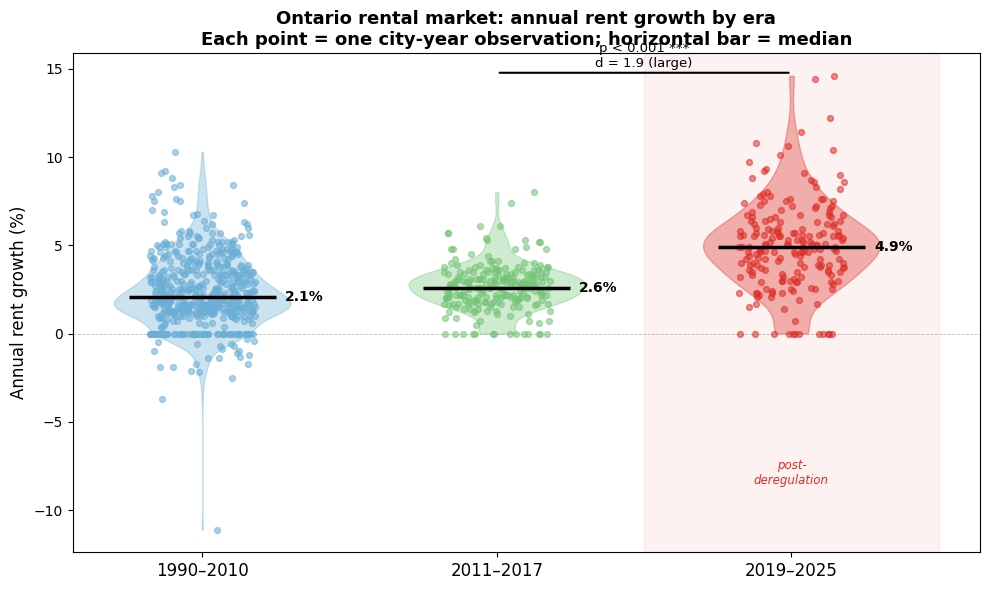

Fig 1 saved.


In [24]:

# ── Cell 7: Fig 1 — Annual rent growth distributions across three eras ────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ERA_COLOURS = {
    "early":     "#6baed6",   # muted blue
    "pre_2018":  "#74c476",   # muted green
    "post_2018": "#de2d26",   # red
}
ERA_DISPLAY = {"early": "1990–2010", "pre_2018": "2011–2017", "post_2018": "2019–2025"}

fig, ax = plt.subplots(figsize=(10, 6))

# Violin plot background, then scatter jitter on top
plot_data = [pct_eras[pct_eras["era"] == e]["rent_pct"].dropna().values
             for e in era_order]

vp = ax.violinplot(plot_data, positions=[1, 2, 3],
                   widths=0.6, showmedians=False, showextrema=False)
for body, era in zip(vp["bodies"], era_order):
    body.set_facecolor(ERA_COLOURS[era])
    body.set_alpha(0.35)
    body.set_edgecolor(ERA_COLOURS[era])

# Jittered raw points
rng = np.random.default_rng(42)
for idx, (era, vals) in enumerate(zip(era_order, plot_data), start=1):
    jitter = rng.uniform(-0.18, 0.18, size=len(vals))
    ax.scatter(idx + jitter, vals, s=18, alpha=0.55,
               color=ERA_COLOURS[era], zorder=3)

# Median lines
for idx, vals in enumerate(plot_data, start=1):
    med = np.median(vals)
    ax.hlines(med, idx - 0.25, idx + 0.25, colors="black", linewidths=2.5, zorder=5)
    ax.text(idx + 0.28, med, f"{med:.1f}%", va="center", fontsize=10, fontweight="bold")

# Deregulation annotation
ax.axhline(0, color="grey", linewidth=0.6, linestyle="--", alpha=0.5)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels([ERA_DISPLAY[e] for e in era_order], fontsize=12)
ax.set_ylabel("Annual rent growth (%)", fontsize=12)
ax.set_title("Ontario rental market: annual rent growth by era\n"
             "Each point = one city-year observation; horizontal bar = median",
             fontsize=13, fontweight="bold")

# Significance bracket: pre_2018 vs post_2018
y_top = ax.get_ylim()[1] * 0.93
ax.annotate("", xy=(3, y_top), xytext=(2, y_top),
            arrowprops=dict(arrowstyle="-", color="black", lw=1.5))
ax.text(2.5, y_top * 1.01, "p < 0.001 ***\nd = 1.9 (large)",
        ha="center", va="bottom", fontsize=9.5)

# Shaded post-2018 region
ax.axvspan(2.5, 3.5, alpha=0.06, color="#de2d26")
ax.text(3, ax.get_ylim()[0] * 0.7, "post-\nderegulation",
        ha="center", va="bottom", fontsize=8.5, color="#de2d26", style="italic")

fig.tight_layout()
plt.savefig("/tmp/fig1_era_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 1 saved.")


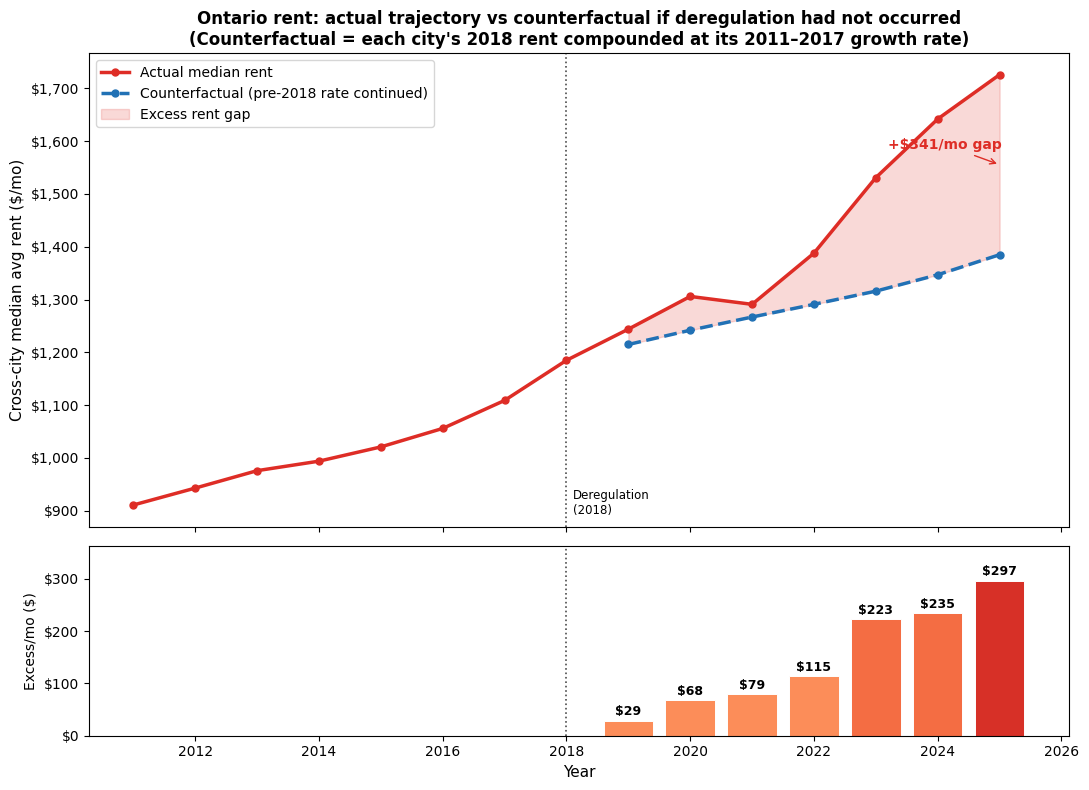

Fig 2 saved.


In [25]:

# ── Cell 8: Fig 2 — Counterfactual rent trajectory 2011–2025 ─────────────────
# Top panel: cross-city median actual vs counterfactual avg rent, shaded gap
# Bottom panel: monthly excess growing over time (bar)

# Build cross-city median actual and CF rent, 2011–2025
actual_yr = (avg_panel[avg_panel["Year"].between(2011, 2025)]
             .groupby("Year")["avg_rent"].median().rename("actual"))

cf_yr = (cf.groupby("year")[["cf_rent","actual_rent","excess_monthly"]]
         .median().rename(columns={"cf_rent":"cf","actual_rent":"actual_cf","excess_monthly":"excess"}))

# For pre-2018 years show actual only (no CF computed there)
all_years = list(range(2011, 2026))
traj = pd.DataFrame({"year": all_years})
traj = traj.merge(actual_yr.reset_index().rename(columns={"Year":"year","actual":"actual_rent"}), on="year", how="left")
traj = traj.merge(cf_yr[["cf","excess"]].reset_index(), on="year", how="left")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8),
                                gridspec_kw={"height_ratios": [2.5, 1]},
                                sharex=True)
fig.subplots_adjust(hspace=0.08)

years_plot = traj["year"].values
act        = traj["actual_rent"].values
cf_line    = traj["cf"].values

# ── top panel ──────────────────────────────────────────────────────────────
ax1.plot(years_plot, act, color="#de2d26", linewidth=2.5, marker="o",
         markersize=5, label="Actual median rent", zorder=4)

# Draw CF line starting from 2018 anchor
cf_years_mask = traj["year"] >= 2018
ax1.plot(traj.loc[cf_years_mask, "year"], traj.loc[cf_years_mask, "cf"],
         color="#2171b5", linewidth=2.5, linestyle="--", marker="o",
         markersize=5, label="Counterfactual (pre-2018 rate continued)", zorder=4)

# Shade the gap post-2018
post_mask = traj["year"] >= 2019
ax1.fill_between(traj.loc[post_mask, "year"],
                 traj.loc[post_mask, "cf"],
                 traj.loc[post_mask, "actual_rent"],
                 alpha=0.18, color="#de2d26", label="Excess rent gap")

# Deregulation line
ax1.axvline(2018, color="black", linewidth=1.2, linestyle=":", alpha=0.7)
ax1.text(2018.1, ax1.get_ylim()[0] * 1.02 if ax1.get_ylim()[0] > 0 else 820,
         "Deregulation\n(2018)", fontsize=8.5, va="bottom", color="black")

ax1.set_ylabel("Cross-city median avg rent ($/mo)", fontsize=11)
ax1.set_title("Ontario rent: actual trajectory vs counterfactual if deregulation had not occurred\n"
              "(Counterfactual = each city's 2018 rent compounded at its 2011–2017 growth rate)",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=10, loc="upper left")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Annotate 2025 gap
act_2025 = traj.loc[traj["year"]==2025, "actual_rent"].values[0]
cf_2025  = traj.loc[traj["year"]==2025, "cf"].values[0]
ax1.annotate(f"+${act_2025 - cf_2025:.0f}/mo gap",
             xy=(2025, (act_2025 + cf_2025) / 2),
             xytext=(2023.2, (act_2025 + cf_2025) / 2 + 30),
             arrowprops=dict(arrowstyle="->", color="#de2d26"),
             fontsize=10, color="#de2d26", fontweight="bold")

# ── bottom panel — monthly excess bar ─────────────────────────────────────
excess_vals = traj.loc[traj["year"] >= 2019, ["year","excess"]].copy()
bar_colours = ["#fc8d59" if e < 150 else "#d73027" if e >= 250 else "#f46d43"
               for e in excess_vals["excess"]]
bars = ax2.bar(excess_vals["year"], excess_vals["excess"],
               color=bar_colours, edgecolor="white", linewidth=0.7)
for bar, val in zip(bars, excess_vals["excess"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             f"${val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.axvline(2018, color="black", linewidth=1.2, linestyle=":", alpha=0.7)
ax2.set_ylabel("Excess/mo ($)", fontsize=10)
ax2.set_xlabel("Year", fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.set_ylim(0, excess_vals["excess"].max() * 1.22)

fig.tight_layout()
plt.savefig("/tmp/fig2_counterfactual_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 2 saved.")


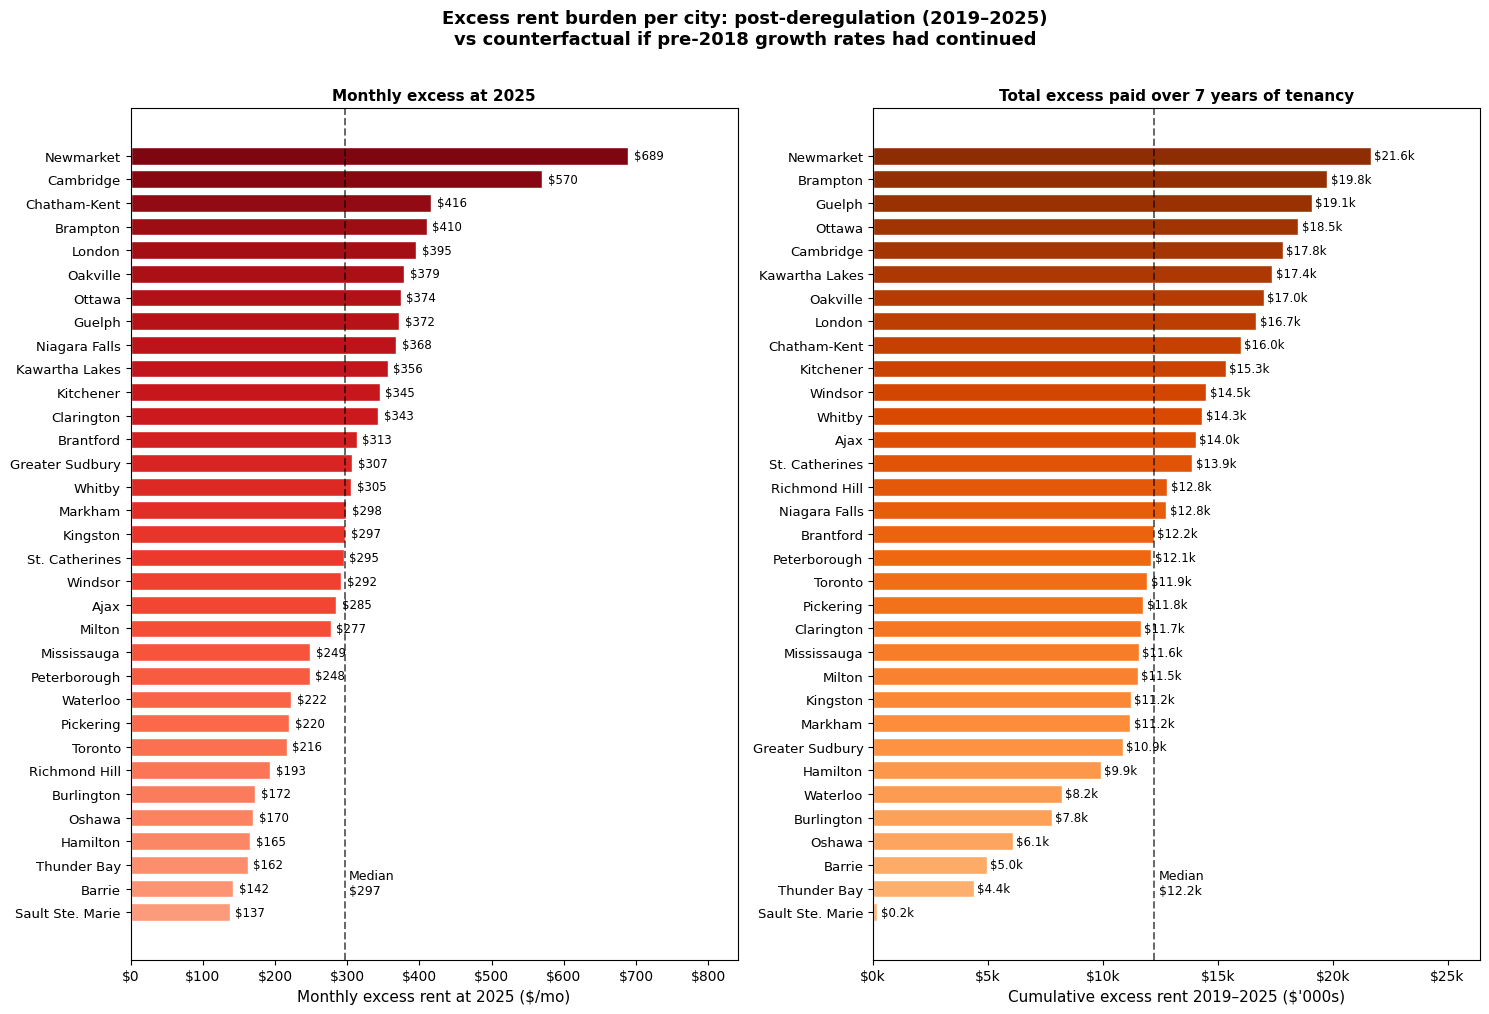

Fig 3 saved.


In [26]:

# ── Cell 9: Fig 3 — City-level excess rent and cumulative burden ──────────────
# Left: monthly excess at 2025 by city (horizontal bar, ranked)
# Right: cumulative excess 2019–2025 by city

# Prep: merge monthly excess at 2025 with cumulative excess
plot_city = (excess_2025[["city","excess_monthly"]]
             .merge(city_excess[["city","cum_excess"]], on="city")
             .sort_values("excess_monthly", ascending=True))

n = len(plot_city)
cmap_val = np.linspace(0.35, 0.95, n)
colours_mo  = plt.cm.Reds(cmap_val)
colours_cum = plt.cm.Oranges(cmap_val)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(15, 10))
fig.suptitle("Excess rent burden per city: post-deregulation (2019–2025)\n"
             "vs counterfactual if pre-2018 growth rates had continued",
             fontsize=13, fontweight="bold", y=1.01)

y_pos = np.arange(n)

# ── Left: monthly excess at 2025 ──────────────────────────────────────────
bars_l = ax_l.barh(y_pos, plot_city["excess_monthly"], color=colours_mo,
                   edgecolor="white", height=0.75)
ax_l.set_yticks(y_pos)
ax_l.set_yticklabels(plot_city["city"].str.title(), fontsize=9.5)
ax_l.set_xlabel("Monthly excess rent at 2025 ($/mo)", fontsize=11)
ax_l.set_title("Monthly excess at 2025", fontsize=11, fontweight="bold")
ax_l.axvline(plot_city["excess_monthly"].median(), color="black",
             linewidth=1.4, linestyle="--", alpha=0.6)
ax_l.text(plot_city["excess_monthly"].median() + 5,
          n * 0.02, f"Median\n${plot_city['excess_monthly'].median():.0f}",
          fontsize=9, va="bottom", color="black")
for bar, val in zip(bars_l, plot_city["excess_monthly"]):
    ax_l.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
              f"${val:,.0f}", va="center", fontsize=8.5)
ax_l.set_xlim(0, plot_city["excess_monthly"].max() * 1.22)
ax_l.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── Right: cumulative excess 2019–2025 ────────────────────────────────────
plot_city_cum = plot_city.sort_values("cum_excess", ascending=True)
colours_cum2  = plt.cm.Oranges(np.linspace(0.35, 0.95, n))
bars_r = ax_r.barh(y_pos, plot_city_cum["cum_excess"] / 1000,
                   color=colours_cum2, edgecolor="white", height=0.75)
ax_r.set_yticks(y_pos)
ax_r.set_yticklabels(plot_city_cum["city"].str.title(), fontsize=9.5)
ax_r.set_xlabel("Cumulative excess rent 2019–2025 ($'000s)", fontsize=11)
ax_r.set_title("Total excess paid over 7 years of tenancy", fontsize=11, fontweight="bold")
med_cum = plot_city_cum["cum_excess"].median() / 1000
ax_r.axvline(med_cum, color="black", linewidth=1.4, linestyle="--", alpha=0.6)
ax_r.text(med_cum + 0.2, n * 0.02, f"Median\n${med_cum:.1f}k",
          fontsize=9, va="bottom", color="black")
for bar, val in zip(bars_r, plot_city_cum["cum_excess"]):
    ax_r.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
              f"${val/1000:,.1f}k", va="center", fontsize=8.5)
ax_r.set_xlim(0, plot_city_cum["cum_excess"].max() / 1000 * 1.22)
ax_r.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}k"))

fig.tight_layout()
plt.savefig("/tmp/fig3_city_excess.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 3 saved.")


In [5]:

# ── Cell 10: Guideline counterfactual — excess above Ontario rent guideline ───
# The Ontario rent increase guideline sets the max % a landlord can raise rent
# for an existing tenant. Post-2018 deregulation exempts new-build units entirely.
# This cell asks: how much have market rents diverged from the guideline path,
# and how does that excess compare pre vs post 2018?

GUIDELINES = {
    1991: 5.4, 1992: 6.0, 1993: 4.9, 1994: 3.2, 1995: 2.9,
    1996: 2.8, 1997: 2.8, 1998: 3.0, 1999: 3.0, 2000: 2.6,
    2001: 2.9, 2002: 3.9, 2003: 2.9, 2004: 2.9, 2005: 1.5,
    2006: 2.1, 2007: 2.6, 2008: 1.4, 2009: 1.8, 2010: 2.1,
    2011: 0.7, 2012: 3.1, 2013: 2.5, 2014: 0.8, 2015: 1.6,
    2016: 2.0, 2017: 1.5, 2018: 1.8, 2019: 1.8, 2020: 2.2,
    2021: 0.0, 2022: 1.2, 2023: 2.5, 2024: 2.5, 2025: 2.5,
}

# ── Part A: Per-city guideline CF from 2018 base, compounded year by year ────
# For each post-2018 year: base_2018 × ∏(1 + guideline_yr / 100) up to that year
gl_rows = []
for city, grp in avg_panel.groupby("city"):
    grp = grp.sort_values("Year")
    base_row = grp[grp["Year"] == 2018]
    if base_row.empty:
        continue
    base_rent = base_row["avg_rent"].iloc[0]

    compound = 1.0
    for yr in range(2019, 2026):
        compound *= (1 + GUIDELINES.get(yr, 0) / 100)
        actual_row = grp[grp["Year"] == yr]
        if actual_row.empty:
            continue
        actual = actual_row["avg_rent"].iloc[0]
        gl_rent = base_rent * compound
        gl_rows.append(dict(
            city=city, year=yr,
            base_rent=round(base_rent, 0),
            gl_rent=round(gl_rent, 0),
            actual_rent=round(actual, 0),
            excess_gl=round(actual - gl_rent, 0),
            excess_gl_annual=round((actual - gl_rent) * 12, 0),
        ))

gl = pd.DataFrame(gl_rows)

# ── Part B: Pre-2018 excess above guideline (2011–2017) ──────────────────────
# For each city-year in 2011–2017: compare actual pct change to guideline for that year
pre_gl_rows = []
for _, row in pct_eras[pct_eras["era"] == "pre_2018"].iterrows():
    gl_rate = GUIDELINES.get(int(row["Year"]), np.nan)
    if np.isnan(gl_rate):
        continue
    pre_gl_rows.append(dict(
        city=row["city"], year=int(row["Year"]),
        actual_pct=row["rent_pct"],
        guideline_pct=gl_rate,
        excess_pp=row["rent_pct"] - gl_rate,  # pp above guideline
    ))

pre_gl = pd.DataFrame(pre_gl_rows)

# ── Summary comparison ────────────────────────────────────────────────────────
gl_2025 = gl[gl["year"] == 2025]
gl_cum  = gl.groupby("city")["excess_gl_annual"].sum().reset_index(
              ).rename(columns={"excess_gl_annual": "cum_excess_gl"})

# Pre-period: mean pp above guideline per city
pre_gl_city = pre_gl.groupby("city")["excess_pp"].mean().reset_index(
                  ).rename(columns={"excess_pp": "mean_pre_excess_pp"})

# Post-period: mean monthly excess above guideline per city
post_gl_city = (gl.groupby("city")[["excess_gl"]].mean().reset_index()
                  .rename(columns={"excess_gl": "mean_post_excess_mo"}))

comparison = pre_gl_city.merge(post_gl_city, on="city").merge(gl_cum, on="city")

# Cross-city summary stats
pre_mean_pp   = pre_gl["excess_pp"].mean()
post_mean_mo  = gl["excess_gl"].mean()
gl_2025_med   = gl_2025["excess_gl"].median()
cum_gl_med    = comparison["cum_excess_gl"].median()

# What was the guideline rate over each period?
gl_pre_mean  = np.mean([GUIDELINES[y] for y in range(2011, 2018)])
gl_post_mean = np.mean([GUIDELINES[y] for y in range(2019, 2026)])

print("Ontario Rent Guideline vs Actual Rent Growth")
print("=" * 60)
print(f"\nGuideline rate mean:  pre-2018 (2011–2017): {gl_pre_mean:.2f}%/yr")
print(f"                      post-2018 (2019–2025): {gl_post_mean:.2f}%/yr")
print(f"Actual growth mean:   pre-2018:  {pct_eras[pct_eras['era']=='pre_2018']['rent_pct'].mean():.2f}%/yr")
print(f"                      post-2018: {pct_eras[pct_eras['era']=='post_2018']['rent_pct'].mean():.2f}%/yr")

print(f"\nPRE-2018 excess above guideline (2011–2017, pct-change basis):")
print(f"  Cross-city-year mean: +{pre_mean_pp:.2f} pp/yr above guideline")
n_above_pre = int((pre_gl["excess_pp"] > 0).sum())
print(f"  City-years above guideline: {n_above_pre}/{len(pre_gl)} ({100*n_above_pre/len(pre_gl):.0f}%)")

print(f"\nPOST-2018 excess above guideline (guideline CF from 2018 base):")
print(f"  Cross-city mean monthly excess: +${post_mean_mo:.0f}/mo")
print(f"  Median monthly excess at 2025:  +${gl_2025_med:.0f}/mo")
print(f"  Median cumulative excess 2019–2025: ${cum_gl_med:,.0f}")
n_above_post = int((gl["excess_gl"] > 0).sum())
print(f"  City-years above guideline: {n_above_post}/{len(gl)} ({100*n_above_post/len(gl):.0f}%)")

print(f"\n{'City':20s}  {'Pre excess (pp/yr)':>18}  {'Post mo excess ($)':>18}  {'Cum excess ($)':>15}")
print("─" * 78)
for _, r in comparison.sort_values("cum_excess_gl", ascending=False).iterrows():
    print(f"  {r['city']:20s}  {r['mean_pre_excess_pp']:>+16.2f}  "
          f"  {r['mean_post_excess_mo']:>14.0f}      ${r['cum_excess_gl']:>10,.0f}")

print()
print("▶  Key finding:")
print(f"   • Pre-2018 market rents were already +{pre_mean_pp:.2f} pp/yr above the guideline on")
print(f"     average — reflecting turnover-driven rent resets even under controlled conditions.")
print(f"   • Post-2018 the guideline gap explodes to a median +${gl_2025_med:.0f}/mo by 2025.")
print(f"   • Over 7 years a tenant in a median-city faces ~${cum_gl_med:,.0f} in cumulative")
print(f"     excess rent above what the guideline would have permitted.")


Ontario Rent Guideline vs Actual Rent Growth

Guideline rate mean:  pre-2018 (2011–2017): 1.74%/yr
                      post-2018 (2019–2025): 1.81%/yr
Actual growth mean:   pre-2018:  2.64%/yr
                      post-2018: 5.00%/yr

PRE-2018 excess above guideline (2011–2017, pct-change basis):
  Cross-city-year mean: +0.89 pp/yr above guideline
  City-years above guideline: 168/224 (75%)

POST-2018 excess above guideline (guideline CF from 2018 base):
  Cross-city mean monthly excess: +$203/mo
  Median monthly excess at 2025:  +$363/mo
  Median cumulative excess 2019–2025: $16,935
  City-years above guideline: 224/231 (97%)

City                  Pre excess (pp/yr)  Post mo excess ($)   Cum excess ($)
──────────────────────────────────────────────────────────────────────────────
  newmarket                        +0.80               307      $    25,784
  oakville                         +1.46               303      $    25,467
  guelph                           +1.19            

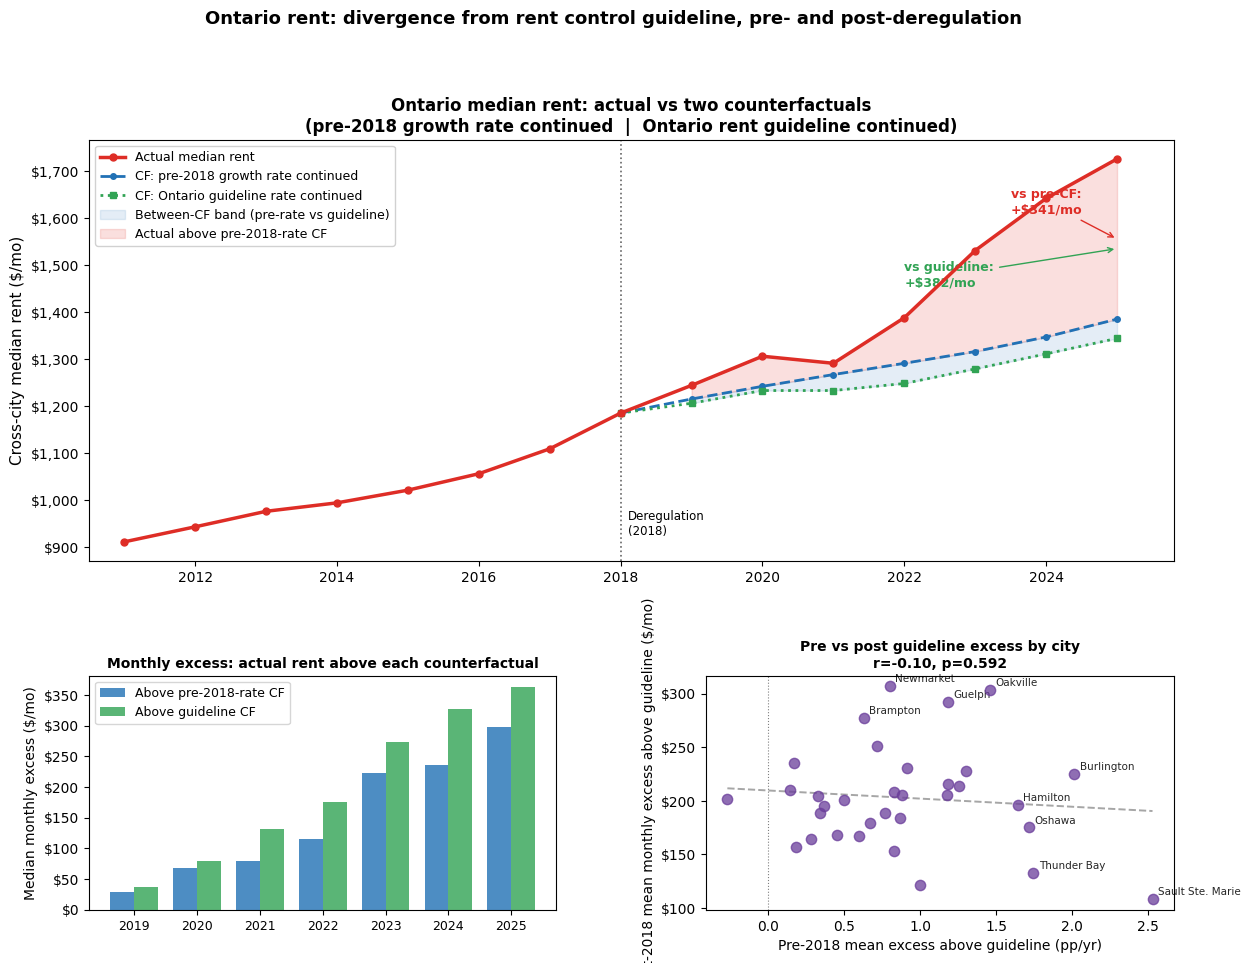

Fig 4 saved.


In [6]:

# ── Cell 11: Fig 4 — Three-scenario rent trajectory + pre/post guideline gap ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

# ── Panel layout: top = trajectory, bottom-left = monthly excess comparison,
#                 bottom-right = pre vs post excess scatter per city ──────────
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.8, 1], hspace=0.35, wspace=0.32)
ax_top = fig.add_subplot(gs[0, :])    # spans full width
ax_bl  = fig.add_subplot(gs[1, 0])   # bottom-left
ax_br  = fig.add_subplot(gs[1, 1])   # bottom-right

# ── Helper: cross-city median trajectories ────────────────────────────────
actual_yr = (avg_panel[avg_panel["Year"].between(2011, 2025)]
             .groupby("Year")["avg_rent"].median())

# Pre-2018-rate CF (from Cell 4 data)
pre_cf_yr  = cf.groupby("year")["cf_rent"].median()
# Guideline CF (from Cell 10 data)
gl_cf_yr   = gl.groupby("year")["gl_rent"].median()

years_top = list(range(2011, 2026))

# Build anchor at 2018 for both CFs
base_2018 = actual_yr[2018]

act_vals   = [actual_yr.get(y, np.nan) for y in years_top]
pre_cf_vals = [base_2018 if y == 2018 else pre_cf_yr.get(y, np.nan) for y in years_top]
gl_cf_vals  = [base_2018 if y == 2018 else gl_cf_yr.get(y, np.nan)  for y in years_top]

# ── Top panel: three trajectories ─────────────────────────────────────────
ax_top.plot(years_top, act_vals, color="#de2d26", lw=2.5, marker="o", ms=5,
            label="Actual median rent", zorder=5)
ax_top.plot(years_top, pre_cf_vals, color="#2171b5", lw=2, ls="--", marker="o", ms=4,
            label="CF: pre-2018 growth rate continued", zorder=4)
ax_top.plot(years_top, gl_cf_vals,  color="#31a354", lw=2, ls=":",  marker="s", ms=4,
            label="CF: Ontario guideline rate continued", zorder=4)

# Shade gap: pre-CF vs guideline CF (the "deregulation vs guideline" band)
post_yrs = [y for y in years_top if y >= 2019]
ax_top.fill_between(post_yrs,
    [gl_cf_yr.get(y, np.nan) for y in post_yrs],
    [pre_cf_yr.get(y, np.nan) for y in post_yrs],
    alpha=0.12, color="#2171b5", label="Between-CF band (pre-rate vs guideline)")
ax_top.fill_between(post_yrs,
    [pre_cf_yr.get(y, np.nan) for y in post_yrs],
    [actual_yr.get(y, np.nan) for y in post_yrs],
    alpha=0.15, color="#de2d26", label="Actual above pre-2018-rate CF")

ax_top.axvline(2018, color="black", lw=1.2, ls=":", alpha=0.6)
ax_top.text(2018.1, min(v for v in act_vals if not np.isnan(v)) * 1.01,
            "Deregulation\n(2018)", fontsize=8.5, va="bottom")

# Annotate 2025 gaps
act_25 = actual_yr[2025]
pre_25 = pre_cf_yr[2025]
gl_25  = gl_cf_yr[2025]
ax_top.annotate(f"vs pre-CF:\n+${act_25-pre_25:.0f}/mo",
    xy=(2025, (act_25+pre_25)/2), xytext=(2023.5, (act_25+pre_25)/2 + 55),
    arrowprops=dict(arrowstyle="->", color="#de2d26"),
    fontsize=9, color="#de2d26", fontweight="bold")
ax_top.annotate(f"vs guideline:\n+${act_25-gl_25:.0f}/mo",
    xy=(2025, (act_25+gl_25)/2), xytext=(2022.0, (act_25+gl_25)/2 - 80),
    arrowprops=dict(arrowstyle="->", color="#31a354"),
    fontsize=9, color="#31a354", fontweight="bold")

ax_top.set_title("Ontario median rent: actual vs two counterfactuals\n"
                 "(pre-2018 growth rate continued  |  Ontario rent guideline continued)",
                 fontsize=12, fontweight="bold")
ax_top.set_ylabel("Cross-city median rent ($/mo)", fontsize=11)
ax_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax_top.legend(fontsize=9, loc="upper left", framealpha=0.9)
ax_top.set_xlim(2010.5, 2025.8)

# ── Bottom-left: year-by-year monthly excess comparison ──────────────────
excess_pre = cf.groupby("year")["excess_monthly"].median()
excess_gl  = gl.groupby("year")["excess_gl"].median()
bar_yrs = list(range(2019, 2026))
x = np.arange(len(bar_yrs))
w = 0.38
ax_bl.bar(x - w/2, [excess_pre[y] for y in bar_yrs], width=w,
          color="#2171b5", alpha=0.8, label="Above pre-2018-rate CF")
ax_bl.bar(x + w/2, [excess_gl[y]  for y in bar_yrs], width=w,
          color="#31a354", alpha=0.8, label="Above guideline CF")
ax_bl.set_xticks(x)
ax_bl.set_xticklabels(bar_yrs, fontsize=9)
ax_bl.set_ylabel("Median monthly excess ($/mo)", fontsize=10)
ax_bl.set_title("Monthly excess: actual rent above each counterfactual", fontsize=10, fontweight="bold")
ax_bl.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax_bl.legend(fontsize=9)

# ── Bottom-right: pre excess pp/yr vs post excess $/mo scatter per city ──
ax_br.scatter(comparison["mean_pre_excess_pp"], comparison["mean_post_excess_mo"],
              s=55, color="#6a3d9a", alpha=0.75, zorder=4)
for _, r in comparison.iterrows():
    if r["mean_post_excess_mo"] > 270 or r["mean_pre_excess_pp"] > 1.5 or r["mean_pre_excess_pp"] < -0.3:
        ax_br.annotate(r["city"].title(),
            (r["mean_pre_excess_pp"], r["mean_post_excess_mo"]),
            fontsize=7.5, xytext=(4, 3), textcoords="offset points", alpha=0.85)

# Regression line
slope_s, intercept_s, r_s, p_s, _ = stats.linregress(
    comparison["mean_pre_excess_pp"], comparison["mean_post_excess_mo"])
xs_s = np.linspace(comparison["mean_pre_excess_pp"].min(),
                   comparison["mean_pre_excess_pp"].max(), 50)
ax_br.plot(xs_s, intercept_s + slope_s * xs_s, color="grey", lw=1.4, ls="--", alpha=0.7)
ax_br.axvline(0, color="black", lw=0.8, ls=":", alpha=0.5)

ax_br.set_xlabel("Pre-2018 mean excess above guideline (pp/yr)", fontsize=10)
ax_br.set_ylabel("Post-2018 mean monthly excess above guideline ($/mo)", fontsize=10)
ax_br.set_title(f"Pre vs post guideline excess by city\nr={r_s:.2f}, p={p_s:.3f}",
                fontsize=10, fontweight="bold")
ax_br.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

fig.suptitle("Ontario rent: divergence from rent control guideline, pre- and post-deregulation",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("/tmp/fig4_guideline_counterfactual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 4 saved.")
